# 03 - Baseline model (climatology)

**What this baseline is:** a simple feed-forward network predicting temperature from
`latitude, longitude, depth` and calendar/seasonal features only. It does **not** see any
surface satellite inputs (SST, SSS, SLA, currents, winds) - it is essentially a learned
**climatology**: "what temperature does this place/depth/time of year usually have?"

**Why that's the right first baseline:** it's cheap to train and gives you a floor number.
If the real CNN+MLP model can't beat this, something is wrong with the surface-input pipeline,
not just the model architecture.

**Why it's not the final baseline:** it has no way to see day-to-day surface conditions, only
average seasonal position. `04_random_forest_baseline.ipynb` is the fairer comparison for the
CNN, since it actually uses SST/SSS/SLA/currents/winds. Compare the CNN against that one, not
this one.

Fixes applied in this version:
- **Data loading now points at the single final file** (`glorys_2021_01_06_regridded_15depth.nc`)
  instead of globbing every `.nc` file in `data/processed/` - after `regrid.py` and the
  preprocessing notebook, that folder also contains the regridded SST/SSS/SLA/currents/wind
  files and intermediate GLORYS files, none of which have a `thetao` variable. The old
  glob-everything approach would now either crash or silently concatenate the wrong data.
- Global random seeds, so results are reproducible.
- Train/val/test split is done by date first, then sampled - guarantees no date appears in
  more than one split.
- Removed dead/duplicate code (features computed twice; an unused `X, y` from the full
  dataframe).
- Added float32 casting before `to_dataframe()` to reduce peak memory.
- Added depth-resolved RMSE/MAE (shallow / thermocline / deep), not just one overall number.
- Saves the trained model, not just the scaler.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Point directly at the final cleaned + regridded + 15-depth GLORYS file -
# this is the same file pairing.py reads. data/processed/ also contains
# other regridded products (SST, SSS, ...) now, so globbing "*.nc" here
# would pick those up too and break this notebook.
GLORYS_PATH = PROCESSED_DIR / "glorys_2021_01_06_regridded_15depth.nc"

if not GLORYS_PATH.exists():
    raise FileNotFoundError(
        f"{GLORYS_PATH} not found. Run regrid.py and 02_preprocessing.ipynb first."
    )

print("Loading:", GLORYS_PATH.name)
ds = xr.open_dataset(GLORYS_PATH)
print(ds)

Loading: glorys_2021_01_06_regridded_15depth.nc
<xarray.Dataset> Size: 264MB
Dimensions:    (time: 181, depth: 15, latitude: 101, longitude: 241)
Coordinates:
  * depth      (depth) int64 120B 0 5 10 20 30 50 ... 150 200 300 500 700 1000
  * time       (time) datetime64[ns] 1kB 2021-01-01 2021-01-02 ... 2021-06-30
  * latitude   (latitude) float64 808B 5.0 5.25 5.5 5.75 ... 29.5 29.75 30.0
  * longitude  (longitude) float64 2kB 45.0 45.25 45.5 ... 104.5 104.8 105.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 264MB ...


In [3]:
print("Dimensions:", dict(ds.dims))
print("\nDepth levels:", ds.depth.values)
print("\nTime range:", str(ds.time.min().values), "to", str(ds.time.max().values))

Dimensions: {'time': 181, 'depth': 15, 'latitude': 101, 'longitude': 241}

Depth levels: [   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]

Time range: 2021-01-01T00:00:00.000000000 to 2021-06-30T00:00:00.000000000


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9500\2476304168.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds.dims))


In [4]:
# Cast to float32 before converting to a DataFrame - to_dataframe() materializes
# every (time, depth, lat, lon) combination at once, so halving the per-value
# size here meaningfully lowers peak memory for this step.
thetao = ds["thetao"].astype("float32")

missing_count = thetao.isnull().sum().item()
print("Missing thetao values:", missing_count)
print("Mean:", thetao.mean().item())
print("Minimum:", thetao.min().item())
print("Maximum:", thetao.max().item())

Missing thetao values: 58435298
Mean: 21.86351203918457
Minimum: 5.677046775817871
Maximum: 34.1840934753418


In [5]:
df = thetao.to_dataframe(name="thetao").reset_index()
print("Original shape:", df.shape)

df = df[df["thetao"].notna()].copy()
print("Shape after selecting valid thetao:", df.shape)
print("\nRemaining missing thetao:", df["thetao"].isna().sum())

del ds, thetao

Original shape: (66085815, 5)
Shape after selecting valid thetao: (7650517, 5)

Remaining missing thetao: 0


In [6]:
df["time"] = pd.to_datetime(df["time"])
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day_of_year"] = df["time"].dt.dayofyear
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

feature_columns = [
    "latitude",
    "longitude",
    "depth",
    "year",
    "day_of_year",
    "month_sin",
    "month_cos"
]
target_column = "thetao"

print("Features:", feature_columns)
print("\nMissing values in features:")
print(df[feature_columns].isna().sum())
print("\nMissing values in target:", df[target_column].isna().sum())

Features: ['latitude', 'longitude', 'depth', 'year', 'day_of_year', 'month_sin', 'month_cos']

Missing values in features:
latitude       0
longitude      0
depth          0
year           0
day_of_year    0
month_sin      0
month_cos      0
dtype: int64

Missing values in target: 0


## Chronological split, done correctly

Date cutoffs are computed first, from the full (unsampled) date range, and rows are assigned
to train/val/test by which side of those cutoffs their date falls on. Sampling down to a
manageable size happens within each split afterwards, so no date can ever appear on both sides
of a split.

In [7]:
SAMPLE_SIZE = 2_000_000
TRAIN_FRAC, VAL_FRAC = 0.70, 0.15  # remaining 0.15 is test

unique_dates = np.sort(df["time"].unique())
n_dates = len(unique_dates)

train_cutoff = unique_dates[int(n_dates * TRAIN_FRAC)]
val_cutoff = unique_dates[int(n_dates * (TRAIN_FRAC + VAL_FRAC))]

train_df = df[df["time"] < train_cutoff]
val_df = df[(df["time"] >= train_cutoff) & (df["time"] < val_cutoff)]
test_df = df[df["time"] >= val_cutoff]

print("Date ranges (no overlap by construction):")
print("Train:", train_df["time"].min(), "to", train_df["time"].max())
print("Val:  ", val_df["time"].min(), "to", val_df["time"].max())
print("Test: ", test_df["time"].min(), "to", test_df["time"].max())

def sample_df(data, frac_of_total):
    n = min(len(data), int(SAMPLE_SIZE * frac_of_total))
    return data.sample(n=n, random_state=SEED)

train_df = sample_df(train_df, TRAIN_FRAC)
val_df = sample_df(val_df, VAL_FRAC)
test_df = sample_df(test_df, 1 - TRAIN_FRAC - VAL_FRAC)

print("\nTrain:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Date ranges (no overlap by construction):
Train: 2021-01-01 00:00:00 to 2021-06-01 00:00:00
Val:   2021-06-02 00:00:00 to 2021-06-08 00:00:00
Test:  2021-06-09 00:00:00 to 2021-06-16 00:00:00

Train: (1400000, 10)
Validation: (300000, 10)
Test: (300000, 10)


In [8]:
X_train = train_df[feature_columns].values
y_train = train_df[target_column].values

X_val = val_df[feature_columns].values
y_val = val_df[target_column].values

X_test = test_df[feature_columns].values
y_test = test_df[target_column].values

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val:  ", X_val.shape, " y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)

X_train: (1400000, 7)  y_train: (1400000,)
X_val:   (300000, 7)  y_val:   (300000,)
X_test:  (300000, 7)  y_test:  (300000,)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, MODELS_DIR / "baseline_scaler.pkl")
print("Scaling completed and scaler saved.")

Scaling completed and scaler saved.


In [10]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

d:\DeepOceanAi\personal\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=1024,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 34.3717 - mae: 2.9609 - val_loss: 2.3762 - val_mae: 1.1137
Epoch 2/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1.5022 - mae: 0.9099 - val_loss: 1.4192 - val_mae: 0.8427
Epoch 3/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9433 - mae: 0.6948 - val_loss: 1.1705 - val_mae: 0.7569
Epoch 4/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7921 - mae: 0.6194 - val_loss: 1.0938 - val_mae: 0.7225
Epoch 5/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.7315 - mae: 0.5855 - val_loss: 1.0676 - val_mae: 0.7207
Epoch 6/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6783 - mae: 0.5626 - val_loss: 1.0305 - val_mae: 0.7038
Epoch 7/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6368 - mae: 0.5445 - val_loss: 1.0179 - val_mae: 0.6962
Epoch 8/100
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.6127 - mae: 0.5350 - val_loss: 1.0150 - val_mae: 0.6946
Epoch 9/100
1368/1368 ━━━━━━━━━

In [21]:
model.save(MODELS_DIR / "baseline_ann.keras")
print("Model saved.")

Model saved.


In [22]:
y_pred = model.predict(X_test_scaled, batch_size=1024).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Baseline ANN Results (all depths combined)")
print("-------------------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R\u00b2  :", r2)

293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step
Baseline ANN Results (all depths combined)
-------------------------------------------
MSE : 1.238476276397705
RMSE: 1.1128684901630135
MAE : 0.746745765209198
R²  : 0.9797783493995667


## Depth-resolved evaluation

Same breakdown used in `04_random_forest_baseline.ipynb`, so the two are directly comparable.

Band                              N      RMSE       MAE        R²
-----------------------------------------------------------------
Shallow (0-100 m)            170296     1.136     0.739     0.752
Thermocline (>100-300 m)      94487     1.381     0.988     0.895
Deep (>300-1000 m)            73037     0.695     0.551     0.917


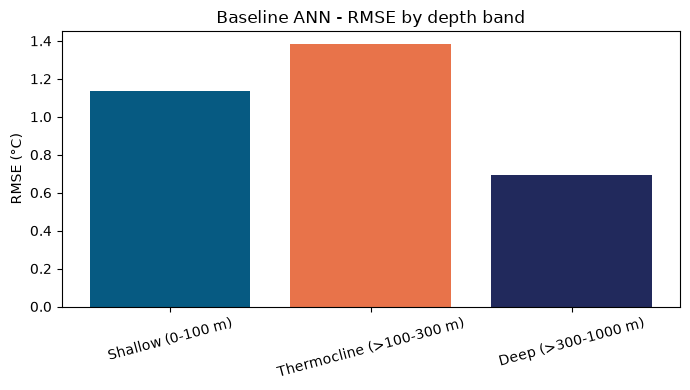

In [23]:
depth_bins = [
    ("Shallow (0-100 m)", 0, 100),
    ("Thermocline (>100-300 m)", 100, 300),
    ("Deep (>300-1000 m)", 300, 1000),
]

test_depths = test_df["depth"].values

print(f"{'Band':<25}{'N':>10}{'RMSE':>10}{'MAE':>10}{'R\u00b2':>10}")
print("-" * 65)
band_results = []
for label, lo, hi in depth_bins:
    mask = (test_depths >= lo) & (test_depths <= hi)
    n = int(mask.sum())
    if n == 0:
        print(f"{label:<25}{n:>10}   (no test points in this band)")
        continue
    band_rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    band_mae = mean_absolute_error(y_test[mask], y_pred[mask])
    band_r2 = r2_score(y_test[mask], y_pred[mask])
    band_results.append((label, band_rmse))
    print(f"{label:<25}{n:>10}{band_rmse:>10.3f}{band_mae:>10.3f}{band_r2:>10.3f}")

plt.figure(figsize=(7, 4))
plt.bar([b[0] for b in band_results], [b[1] for b in band_results], color=["#065A82", "#E8734A", "#21295C"])
plt.ylabel("RMSE (\u00b0C)")
plt.title("Baseline ANN - RMSE by depth band")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

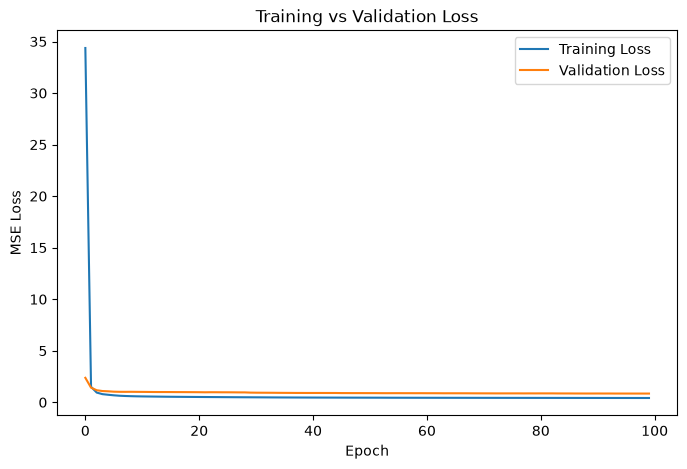

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

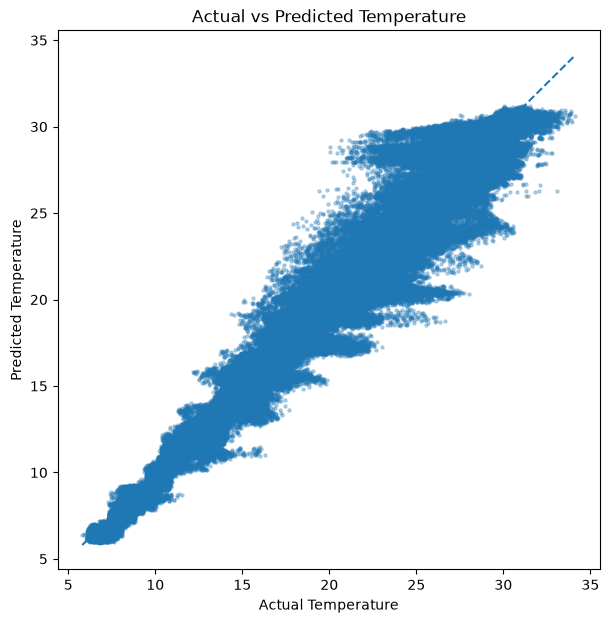

In [25]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, s=5, alpha=0.3)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

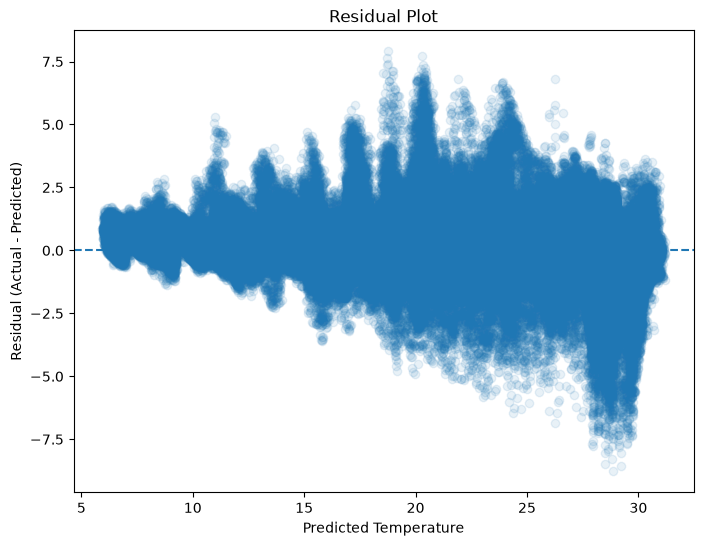

In [26]:
errors = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, errors, alpha=0.1)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Temperature")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

# Expected pattern for this baseline: it only sees latitude/longitude/depth/
# time, so it can only learn the average seasonal temperature at a location,
# not day-to-day surface conditions. Compare against
# 04_random_forest_baseline.ipynb, which actually uses surface variables.